In [2]:
import numpy as np
import matplotlib.pyplot as plt

this exercise is taken from chapter 3 of "Information Theory, Inference, and Learning Algorithms" by David MacKay; i recall the bayes theorem:
$$
    P(\lambda|x) = \frac{P(x|\lambda) \ P(\lambda)}{P(x)}
$$
in our case, $P(x|\lambda)$, namely the likelihood is:
$$
    P(x|\lambda) = \frac{1}{\lambda Z(\lambda)}e^{-x / \lambda} \ \ \ 1<x<20;  \ \ \ \Rightarrow \ \ \ P(\lambda|x) \propto \frac{1}{\lambda Z(\lambda)}e^{-x / \lambda} \ P(\lambda)
$$
the normalisation constant $Z(\lambda)$ is simple to compute: 
$$
    \int_{1}^{20} \frac{1}{\lambda Z(\lambda)}e^{-x / \lambda} dx =1 \ \ \ \Rightarrow \ \ \ Z(\lambda) = e^{-1/\lambda} - e^{-20/\lambda}
$$

In [3]:
#normalisation
def z(lamb):
    return np.exp(-1/lamb) - np.exp(-20/lamb)

#likelihood
def likelihood(x, lamb):
    return 1/(lamb * z(lamb)) * np.exp(-x/lamb)

#data set
x0 = np.array([1.5, 2, 3, 4, 5, 12])

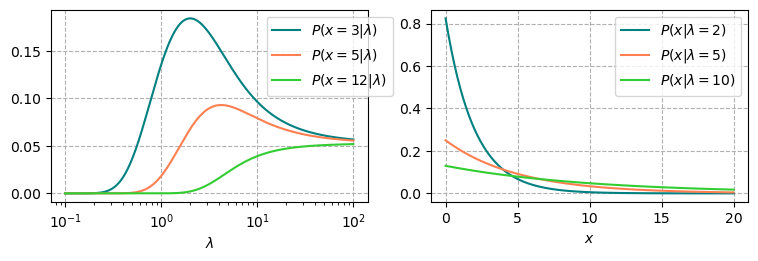

In [69]:
xAr = np.linspace(0, 20, 100)
lambAr = np.linspace(.1, 100, 10000)

#probability of lambda for different values of x (as a function of lambda)
likX3 = likelihood(3, lambAr)
likX5 = likelihood(5, lambAr)
likX12 = likelihood(12, lambAr)

#probability of x for different values of lambda (as a function of x)
likL2 = likelihood(xAr, 2)
likL5 = likelihood(xAr, 5)
likL10 = likelihood(xAr, 10)

fig = plt.figure(figsize=(9, 2.5))
grid = plt.GridSpec(1, 2)

plt1 = fig.add_subplot(grid[0, 0])  
plt1.plot(lambAr, likX3, label=r'$P(x=3|\lambda)$', color='teal')
plt1.plot(lambAr, likX5, label=r'$P(x=5|\lambda)$', color='coral')
plt1.plot(lambAr, likX12, label=r'$P(x=12|\lambda)$', color='limegreen')
plt1.grid(linestyle='dashed')
plt1.set_xscale('log')
plt1.set_xlabel(r'$\lambda$')
plt1.legend(loc='upper right',bbox_to_anchor=(1.1, 1))

plt2 = fig.add_subplot(grid[0, 1])
plt2.plot(xAr, likL2, label=r'$P(x|\lambda=2)$', color='teal')
plt2.plot(xAr, likL5, label=r'$P(x|\lambda=5)$', color='coral')
plt2.plot(xAr, likL10, label=r'$P(x|\lambda=10)$', color='limegreen')
plt2.grid(linestyle='dashed')
plt2.set_xlabel(r'$x$')
plt2.legend(loc='upper right')
plt.show()

#### uniform prior at each step
at each step we take a uniform prior (as the example in the book): the posterior is simply the product of the likelihoods; 

the maximum at posteriori for the decay length is: 3.696759675967597


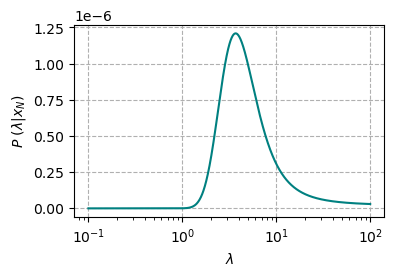

In [73]:
posterior = [np.zeros(len(lambAr))]*len(x0)

for i in range(len(x0)):
    posterior[i] = likelihood(x0[i], lambAr)

post = np.prod(posterior, axis=0)

fig = plt.figure(figsize=(4, 2.5))
plt.plot(lambAr, post, color='teal')
plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$P\ (\lambda|{x}_N)$')
plt.grid(linestyle='dashed')

print(f'the maximum at posteriori for the decay length is: {lambAr[post.argmax()]}')

#### updating the prior: posterior[i] = prior[i+1]
now, we update the prior at each step; the posterior of the step $i$, becomes the prior of the step $i+1$. namely:
$$
    P(\lambda | x_{i+1}) = \frac{P(x_{i+1} | \lambda) \ P(\lambda | x_i)}{P(x_{i+1})}
$$

the maximum at posteriori for the decay length is: 2.657695769576958


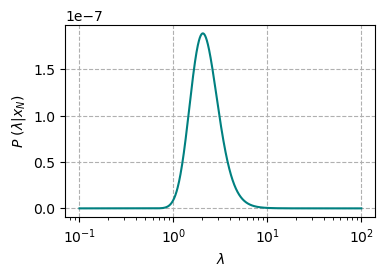

In [59]:
posteriorUp = [np.zeros(len(lambAr))]*len(x0)

for i in range(len(x0)-1):
    posteriorUp[i] = likelihood(x0[i], lambAr)
    posteriorUp[i+1] = likelihood(x0[i], lambAr) * posteriorUp[i]

postUp = np.prod(posteriorUp, axis=0)

fig = plt.figure(figsize=(4, 2.5))
plt.plot(lambAr, postUp*(1/lambAr**2), color='teal')
plt.xscale('log')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$P\ (\lambda|{x}_N)$')
plt.grid(linestyle='dashed')

print(f'the maximum at posteriori for the decay length is: {lambAr[postUp.argmax()]}')


#### uniform prior and "updated" prior

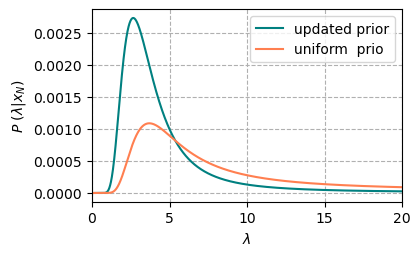

In [58]:
fig = plt.figure(figsize=(4, 2.5))
plt.plot(lambAr, postUp/np.trapz(postUp), color='teal', label='updated prior')
plt.plot(lambAr, post/np.trapz(post), color= 'coral', label='uniform  prio')
#plt.xscale('log')
plt.xlim(0,20)
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$P\ (\lambda|{x}_N)$')
plt.grid(linestyle='dashed')
plt.legend()#loc = 'upper right', bbox_to_anchor=(1.2, 1))
plt.show()

#### Laplace approximation
with Laplace approximation, we approximate the posterior $P(\lambda|x)$ with a gaussian around the maximum at posteriori $x_0$: 
$$
    P(\lambda|x=x_0) \sim \mathcal{N}(\mu = x_0, \ \ \sigma^2 = \Big\{-\frac{d^2}{d\lambda^2} \log\Big[ P(\lambda|x) \Big] \Bigg|_{x=x_0}\Big \} ^{-1})
$$

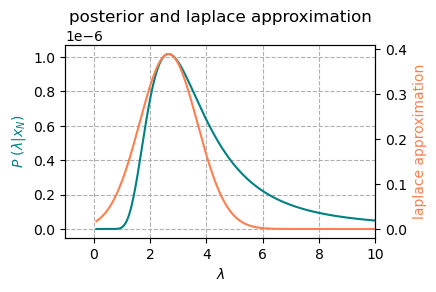

In [77]:
indexMax = np.argmax(postUp)
gradient = np.gradient(np.log(postUp), lambAr)
sigmaN = (-np.gradient(gradient, lambAr)[indexMax])**(-0.5)

def gauss(x, mu, sigma):
    return 1/((2*np.pi*(sigma)**2)**0.5) * np.exp(-1/2*(((x-mu)**2)/((sigma)**2)))

laplace = gauss(lambAr, lambAr[indexMax], sigmaN)

fig, plt1 = plt.subplots(facecolor=(1, 1, 1), figsize=(4, 2.5))
plt1.plot(lambAr, postUp, color='teal')
plt1.set_xlim(-1, 10)
#plt.xscale('log')
plt1.set_xlabel(r'$\lambda$')
plt1.set_ylabel(r'$P\ (\lambda|{x}_N)$', color='teal')
plt1.grid(linestyle='dashed')

plt2 = plt1.twinx()
plt2.plot(lambAr, laplace, color='coral')
plt2.set_ylabel('laplace approximation', color='coral')

plt.title('posterior and laplace approximation')
plt.show()